In [1]:
cd ..

/Users/harini/Dropbox (MIT)/Harini Narayanan’s files/Home/CodonOptimization/Models/2Target_Pichia/BO_forHyperParameter


In [2]:
import math
import collections
import pickle
import random
%matplotlib inline
from matplotlib import pyplot as plt

import GPy
from GPy import likelihoods
import numpy as np
import pandas as pd
from tqdm import tqdm

# from Kernel import MixtureViaSumAndProduct, CategoryOverlapKernel
from InitialData_Gen import initialize

# from SamplingCategorical import compute_prob_dist_and_draw_hts
from UpdateCategoricalWeight import compute_reward_for_all_cat_variable, update_weights_for_all_cat_var

from AskTell import ask_tell

from scipy.optimize import minimize

from typing import Union, Tuple
from paramz.transformations import Logexp
import scipy
from scipy.optimize import minimize
from scipy.optimize import NonlinearConstraint



# np.random.seed(37)

In [3]:
bounds = [  {'name': 'Enc hidden size', 'type': 'continuous', 'domain': (60, 515)},
            {'name': 'Enc Embedding size', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Dec Embedding size', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Dense Layer size', 'type': 'continuous', 'domain': (30, 260)},
          {'name': 'Dense Layer size aa', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Drop rate', 'type': 'continuous', 'domain': (0, 0.9)},
          {'name': 'Drop rate aa', 'type': 'continuous', 'domain': (0, 0.9)}]

Nx = len(bounds)
initN = 12
Niter = 1
batch_size = 3
approach_type = 'Co'
prob_type = 'UnConstrained'

data_param = {'Nx': Nx, 'nDim': Nx, 'bounds': bounds, 
              'approach_type': approach_type,
              'prob_type': prob_type, 'initN': initN}

In [6]:
runs0 = [0, 1, 2, 3, 4, 5, 6, 8, 9, 10 ,11]
data0 = pd.read_csv('./Arch1/InitialRound_HyperParameter.csv').iloc[runs0,1:].values
result0 = np.zeros((len(runs0), 1))

for i in range(len(runs0)):
    filename = '../EncDec_Arch1/Loss_Evolution/Initial/Combo' + str(runs0[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result0[i] = output[-1,-2] *  output[-1,-1]
    
runs1 = [0, 1, 2]
data1 = pd.read_csv('./Arch1/Round1.csv').iloc[runs1,1:].values
result1 = np.zeros((len(runs1), 1))

for i in range(len(runs1)):
    filename = '../EncDec_Arch1/Loss_Evolution/Round1/Combo' + str(runs1[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result1[i] = output[-1,-2] *  output[-1,-1]
    

data = np.concatenate((data0, data1), axis = 0)
result = np.concatenate((result0, result1), axis = 0)

check2

Name : GP regression
Objective : 2.8453396882877913
Number of Parameters : 9
Number of Optimization Parameters : 9
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  Mat32.variance           |      1.8817683892870118  |      +ve      |        
  Mat32.lengthscale        |                    (7,)  |      +ve      |        
  Gaussian_noise.variance  |  5.562684646268137e-309  |      +ve      |        


 /Users/harini/Desktop/python_venv/lib/python3.7/site-packages/scipy/optimize/_hessian_update_strategy.py:186: UserWarning:delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.


`gtol` termination condition is satisfied.
Number of iterations: 52, function evaluations: 352, CG iterations: 93, optimality: 6.97e-09, constraint violation: 0.00e+00, execution time: 0.27 s.
`gtol` termination condition is satisfied.
Number of iterations: 45, function evaluations: 296, CG iterations: 84, optimality: 7.27e-09, constraint violation: 0.00e+00, execution time: 0.23 s.
`gtol` termination condition is satisfied.
Number of iterations: 51, function evaluations: 328, CG iterations: 82, optimality: 7.76e-09, constraint violation: 0.00e+00, execution time: 0.29 s.
`gtol` termination condition is satisfied.
Number of iterations: 46, function evaluations: 304, CG iterations: 89, optimality: 4.20e-09, constraint violation: 0.00e+00, execution time: 0.25 s.
`gtol` termination condition is satisfied.
Number of iterations: 49, function evaluations: 336, CG iterations: 84, optimality: 8.32e-09, constraint violation: 0.00e+00, execution time: 0.29 s.
`gtol` termination condition is sat

`gtol` termination condition is satisfied.
Number of iterations: 42, function evaluations: 272, CG iterations: 71, optimality: 3.96e-09, constraint violation: 0.00e+00, execution time: 0.22 s.
`gtol` termination condition is satisfied.
Number of iterations: 40, function evaluations: 256, CG iterations: 62, optimality: 1.90e-09, constraint violation: 0.00e+00, execution time:  0.2 s.
`gtol` termination condition is satisfied.
Number of iterations: 43, function evaluations: 280, CG iterations: 62, optimality: 7.52e-09, constraint violation: 0.00e+00, execution time: 0.21 s.
`gtol` termination condition is satisfied.
Number of iterations: 48, function evaluations: 320, CG iterations: 83, optimality: 8.12e-09, constraint violation: 0.00e+00, execution time: 0.24 s.
`gtol` termination condition is satisfied.
Number of iterations: 48, function evaluations: 320, CG iterations: 97, optimality: 3.71e-09, constraint violation: 0.00e+00, execution time: 0.26 s.
`gtol` termination condition is sat

 /Users/harini/Desktop/python_venv/lib/python3.7/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


`gtol` termination condition is satisfied.
Number of iterations: 50, function evaluations: 344, CG iterations: 73, optimality: 2.40e-09, constraint violation: 0.00e+00, execution time: 0.28 s.
`gtol` termination condition is satisfied.
Number of iterations: 42, function evaluations: 280, CG iterations: 89, optimality: 9.65e-09, constraint violation: 0.00e+00, execution time: 0.27 s.
`gtol` termination condition is satisfied.
Number of iterations: 53, function evaluations: 376, CG iterations: 85, optimality: 7.33e-09, constraint violation: 0.00e+00, execution time: 0.31 s.
`gtol` termination condition is satisfied.
Number of iterations: 59, function evaluations: 416, CG iterations: 111, optimality: 4.34e-09, constraint violation: 0.00e+00, execution time: 0.36 s.
`gtol` termination condition is satisfied.
Number of iterations: 38, function evaluations: 240, CG iterations: 54, optimality: 8.13e-09, constraint violation: 0.00e+00, execution time: 0.19 s.
`gtol` termination condition is sa

`gtol` termination condition is satisfied.
Number of iterations: 63, function evaluations: 448, CG iterations: 94, optimality: 3.09e-09, constraint violation: 0.00e+00, execution time: 0.33 s.
`gtol` termination condition is satisfied.
Number of iterations: 50, function evaluations: 344, CG iterations: 73, optimality: 3.70e-09, constraint violation: 0.00e+00, execution time: 0.25 s.
`gtol` termination condition is satisfied.
Number of iterations: 57, function evaluations: 448, CG iterations: 89, optimality: 3.00e-09, constraint violation: 0.00e+00, execution time:  0.3 s.
`gtol` termination condition is satisfied.
Number of iterations: 57, function evaluations: 400, CG iterations: 113, optimality: 8.00e-09, constraint violation: 0.00e+00, execution time:  0.3 s.
`gtol` termination condition is satisfied.
Number of iterations: 49, function evaluations: 344, CG iterations: 97, optimality: 7.96e-09, constraint violation: 0.00e+00, execution time: 0.25 s.
`gtol` termination condition is sa

`gtol` termination condition is satisfied.
Number of iterations: 50, function evaluations: 328, CG iterations: 73, optimality: 9.29e-09, constraint violation: 0.00e+00, execution time: 0.25 s.
`gtol` termination condition is satisfied.
Number of iterations: 60, function evaluations: 424, CG iterations: 133, optimality: 5.70e-09, constraint violation: 0.00e+00, execution time: 0.34 s.
`gtol` termination condition is satisfied.
Number of iterations: 53, function evaluations: 352, CG iterations: 84, optimality: 5.01e-09, constraint violation: 0.00e+00, execution time: 0.28 s.
`gtol` termination condition is satisfied.
Number of iterations: 59, function evaluations: 400, CG iterations: 120, optimality: 4.10e-09, constraint violation: 0.00e+00, execution time: 0.31 s.
`gtol` termination condition is satisfied.
Number of iterations: 51, function evaluations: 336, CG iterations: 80, optimality: 1.96e-09, constraint violation: 0.00e+00, execution time: 0.27 s.
`gtol` termination condition is s

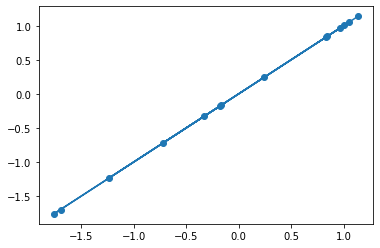

In [13]:
Wc_list = []
gamma_list = []
    
# for i in range(Niter):
X_exp, f_val, gp = ask_tell(data, result,data_param,
                        'Matern32', 'constant_liar', batch_size,  Wc_list, gamma_list) #thompson_sampling

X_ts_norm = (X_exp - np.mean(data, 0))/np.std(data, 0)
print(X_ts_norm)
Yp = gp.predict(X_ts_norm)
print(Yp)

In [14]:
column_names = []
for i in range(len(bounds)):
    column_names.append(data_param['bounds'][i]['name'])
    

X_exp[:,0:-2] = np.round(X_exp[:,0:-2])
X_exp[:,-2:] = np.round(X_exp[:,-2:],1)
X_exp_df = pd.DataFrame(X_exp)
X_exp_df.columns = column_names


pd.DataFrame(X_exp_df).to_csv('./Arch1/Round2.csv')

In [ ]:
column_names

In [15]:
X_exp_df

,Enc hidden size,Enc Embedding size,Dec Embedding size,Dense Layer size,Dense Layer size aa,Drop rate,Drop rate aa
0,60.0,235.0,130.0,30.0,199.0,0.0,0.0
1,60.0,151.0,148.0,30.0,152.0,0.9,0.0
2,193.0,83.0,215.0,260.0,152.0,0.9,0.0
